# Visual analysis
This notebook contains all the visualization used within the thesis.

In [53]:
import sys

sys.path.append("../src")  # go to parent dir
import json
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from plot_utils import plot_fairness_metrics, plot_utility_metrics

warnings.filterwarnings("ignore")

In [54]:
def load_data(path):
    with open(path, "r") as f:
        data = json.load(f)
    
    return pd.DataFrame.from_dict(data).rename_axis(index=str)


## Metrics vs Penalty

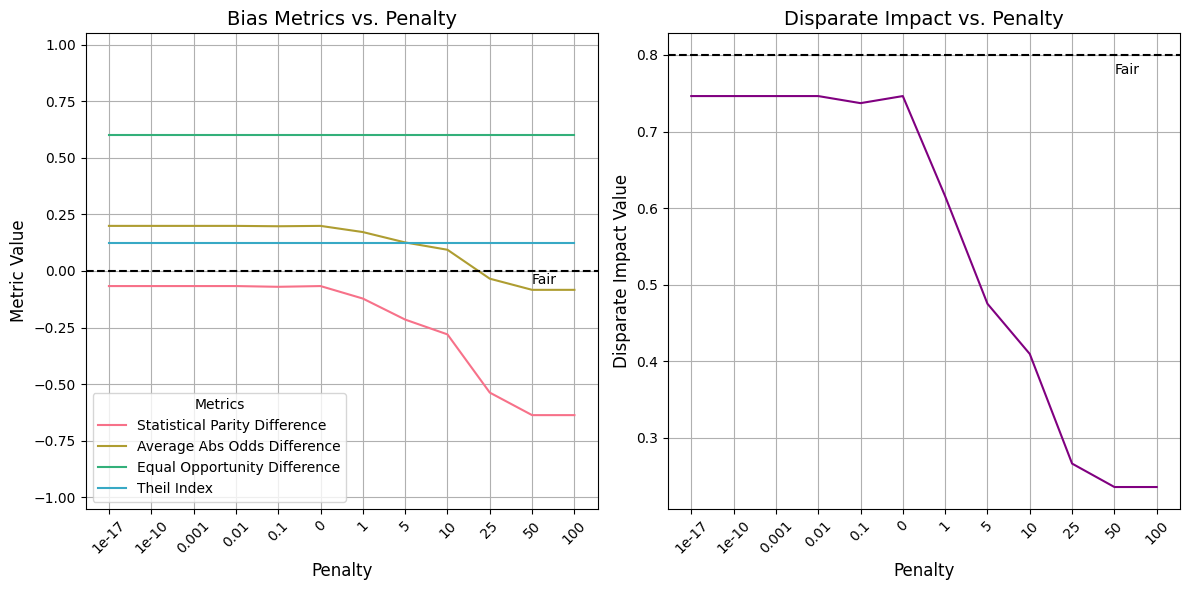

In [55]:
plot_fairness_metrics(load_data("./data/fairness_metrics_original.json"), "lower left", -0.04, 0.78, )

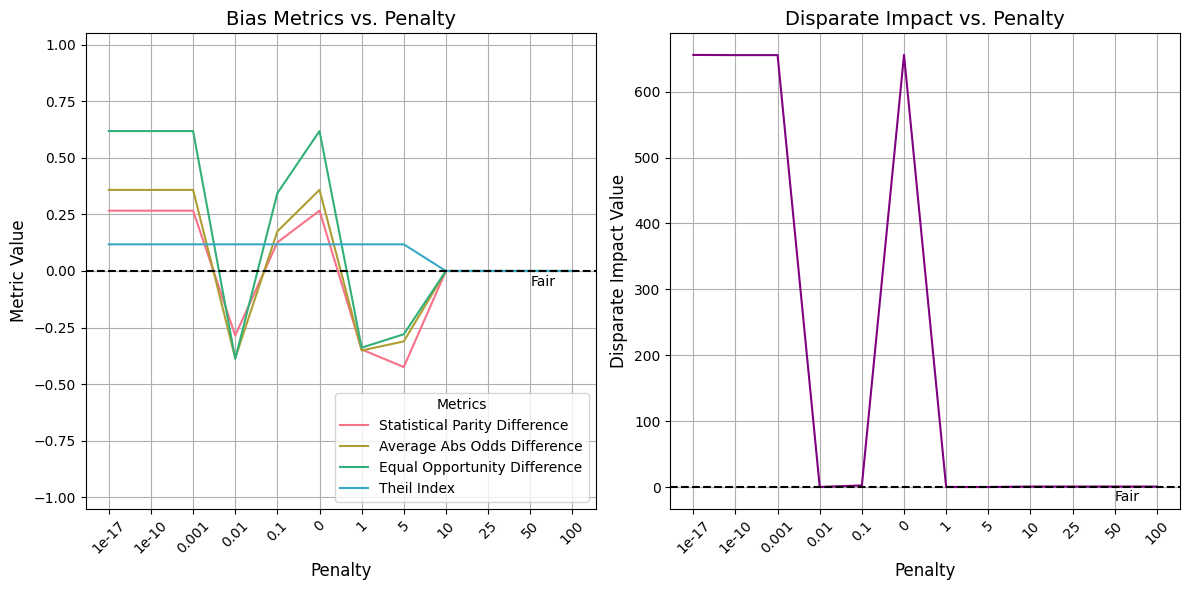

In [56]:
plot_fairness_metrics(load_data("./data/fairness_metrics_original_binning.json"), "lower right", -0.05, -15)

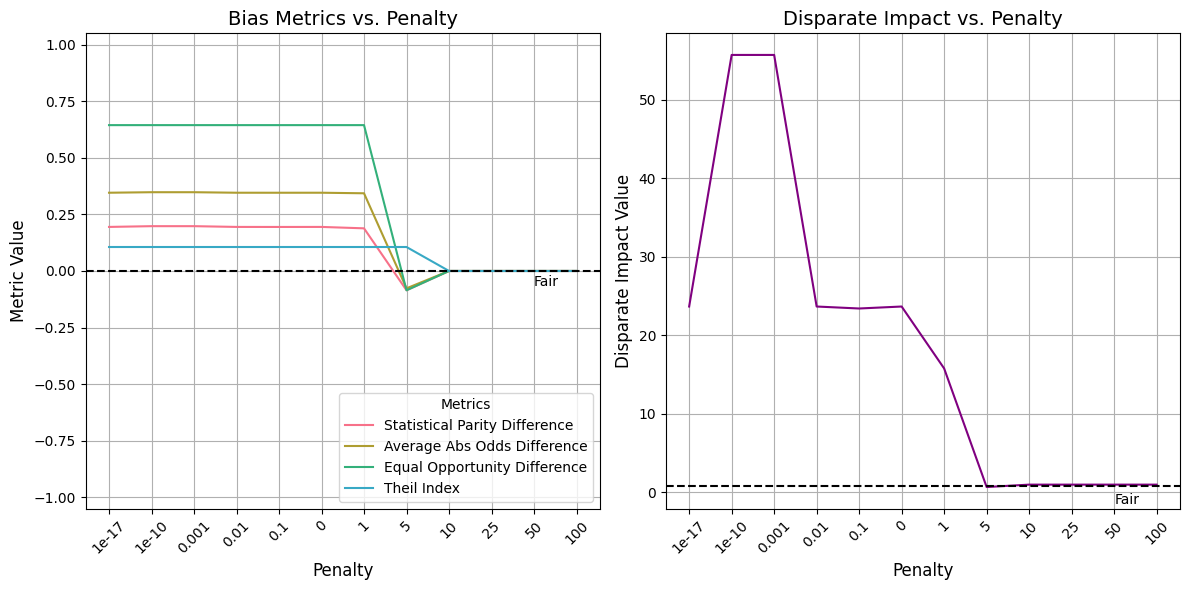

In [57]:
plot_fairness_metrics(load_data("./data/fairness_metrics_original_pdf.json"), "lower right", -0.05, -1)

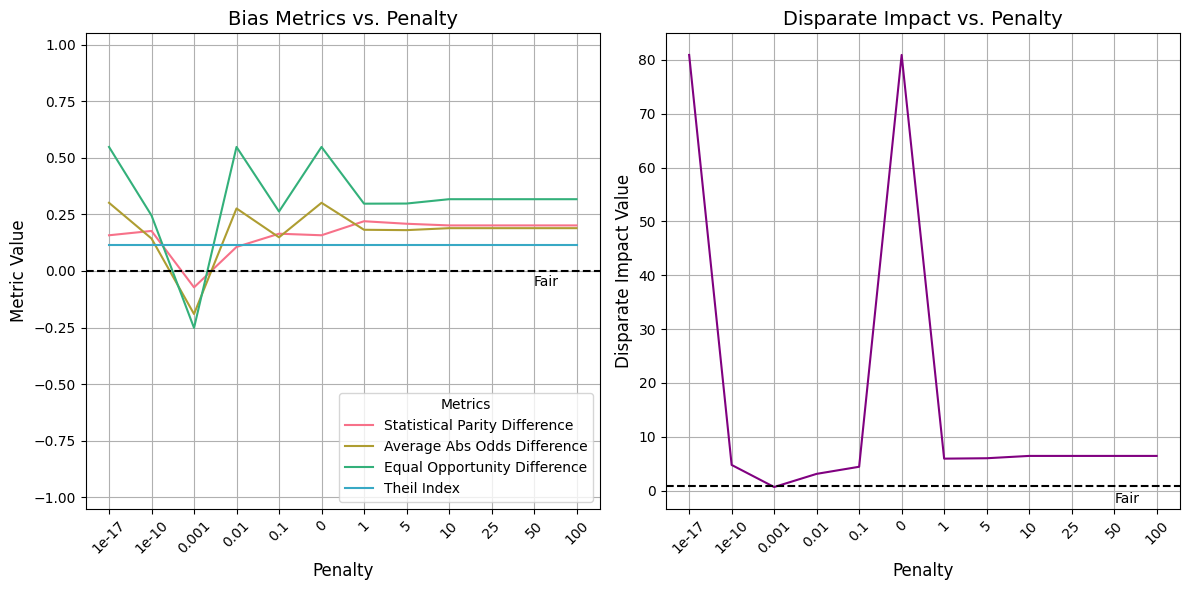

In [58]:
plot_fairness_metrics(load_data("./data/fairness_metrics_synthetic.json"), "lower right", -0.05, -1.5)

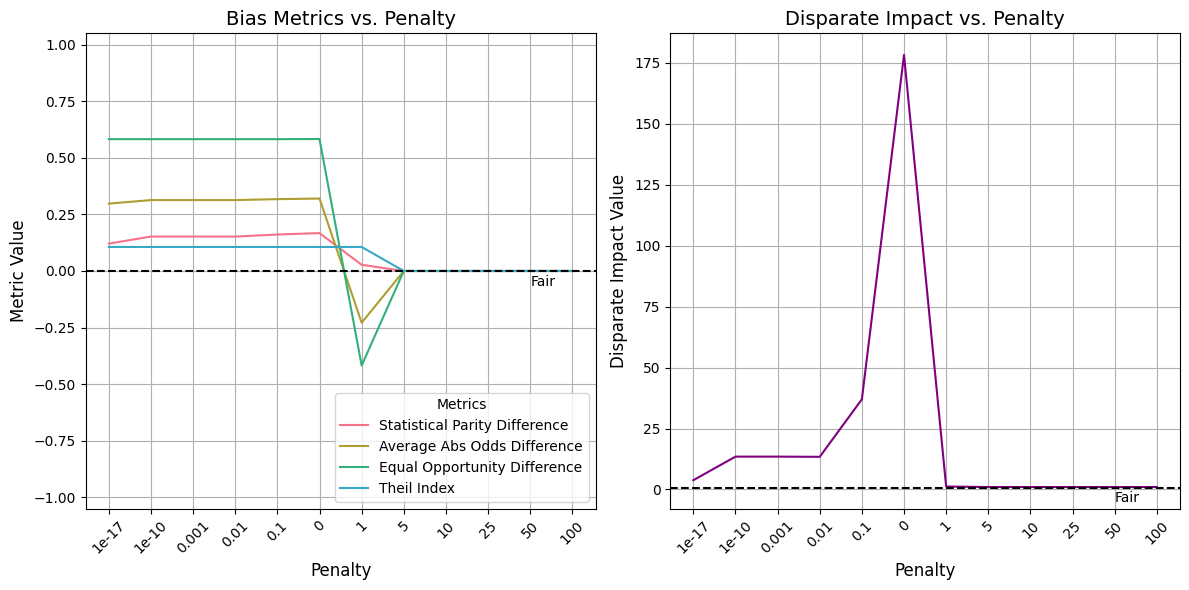

In [59]:
plot_fairness_metrics(load_data("./data/fairness_metrics_synthetic_binning.json"), "lower right", -0.05, -3.5)

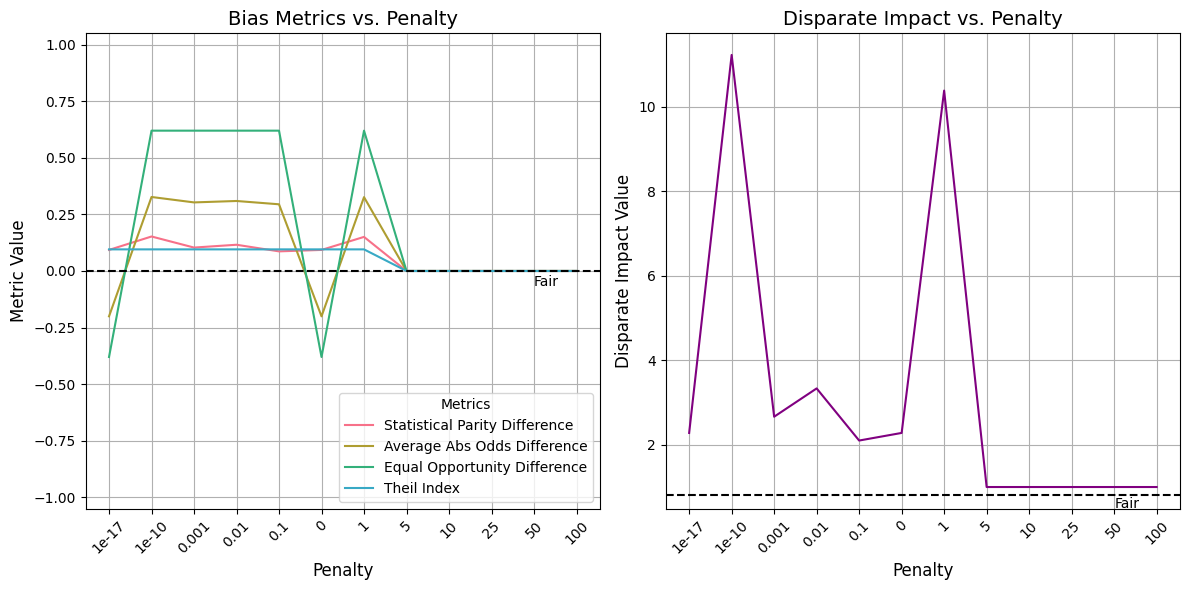

In [60]:
plot_fairness_metrics(load_data("./data/fairness_metrics_synthetic_pdf.json"), "lower right", -0.05, 0.6)

## 25 iterations penalty vs metrics

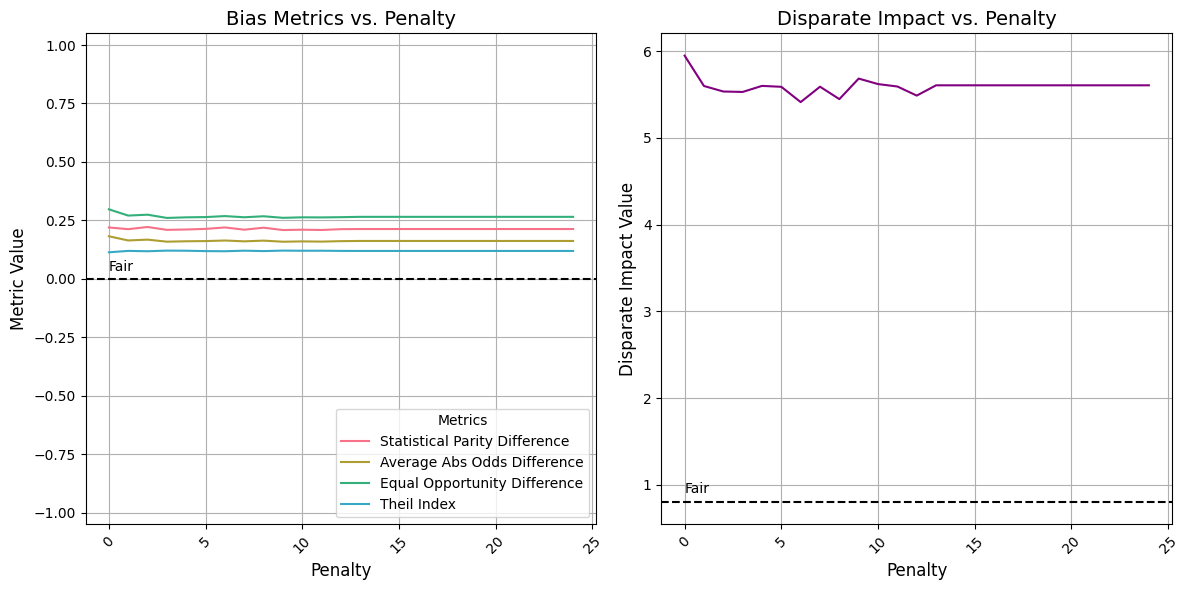

In [61]:
df_fairness_metrics = load_data('./data/fairness_metrics_25_iterations_synthetic.json')
df_fairness_metrics.index = df_fairness_metrics.index.str.extract(r'mitigation_(\d+)')[0].astype(int)
plot_fairness_metrics(df_fairness_metrics, "lower right", 0.05, 0.95, df_fairness_metrics.index.min())

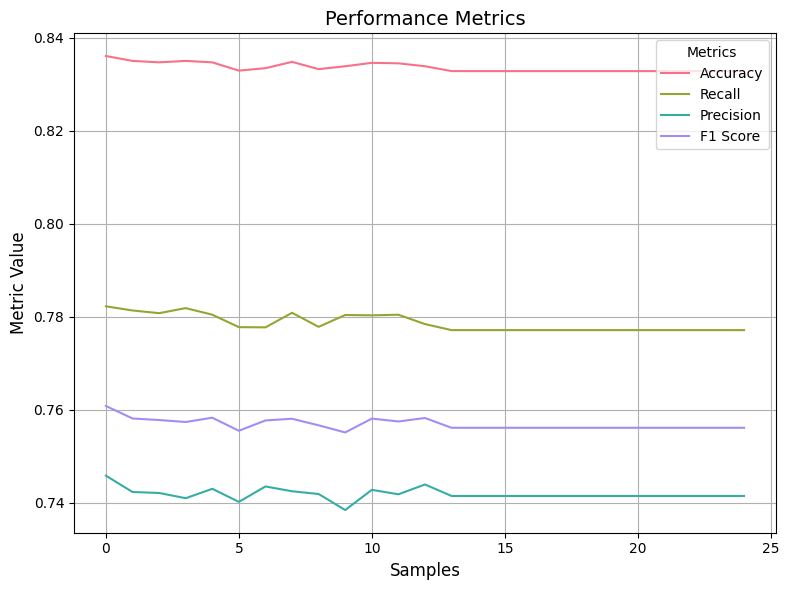

In [62]:
df_metrics_loaded = load_data('./data/utility_metrics_25_iterations_synthetic.json')
df_metrics_loaded.index = df_metrics_loaded.index.str.extract(r'mitigation_(\d+)')[0].astype(int)
df_metrics_loaded.columns = ['Accuracy', 'Recall', 'Precision', 'F1 Score']
plot_utility_metrics(df_metrics_loaded, label_pos='upper right')

## Binning vs PDF

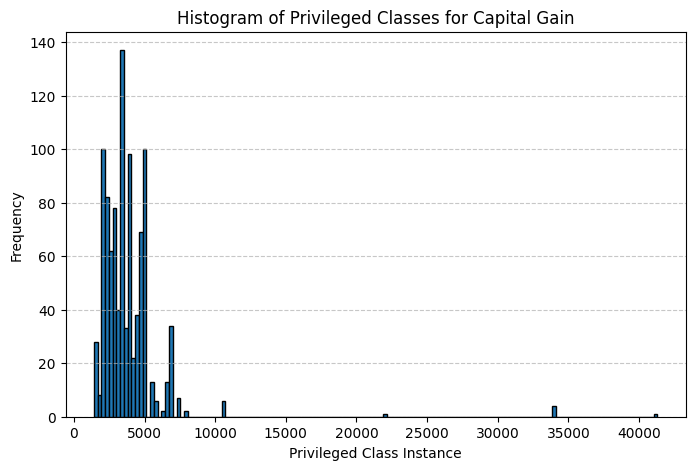

In [63]:
# Example DataFrame (Replace this with your actual DataFrame)
df = pd.read_json("../data/trainset.json")

# Define privileged values (Replace with actual privileged class values)
privileged_values = [
    1409, 1424, 1455, 1506, 1797, 2105, 2174,
    2202, 2228, 2290, 2329, 2346, 2354, 2407,
    2414, 2463, 2580, 2597, 2635, 2653, 2829,
    2885, 2907, 2936, 2961, 3137, 3273, 3325,
    3411, 3432, 3456, 3464, 3471, 3674, 3781,
    3818, 3908, 3942, 4064, 4101, 4416, 4508,
    4650, 4865, 4931, 5013, 5455, 5721, 6360,
    6497, 6723, 6767, 6849, 7443, 7978, 10566,
    22040, 34095, 41310
]

# Filter the DataFrame to keep only privileged values
df_privileged = df[df['capital-gain'].isin(privileged_values)]

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(df_privileged['capital-gain'], bins=150, edgecolor='black')
plt.xlabel('Privileged Class Instance')
plt.ylabel('Frequency')
plt.title('Histogram of Privileged Classes for Capital Gain')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


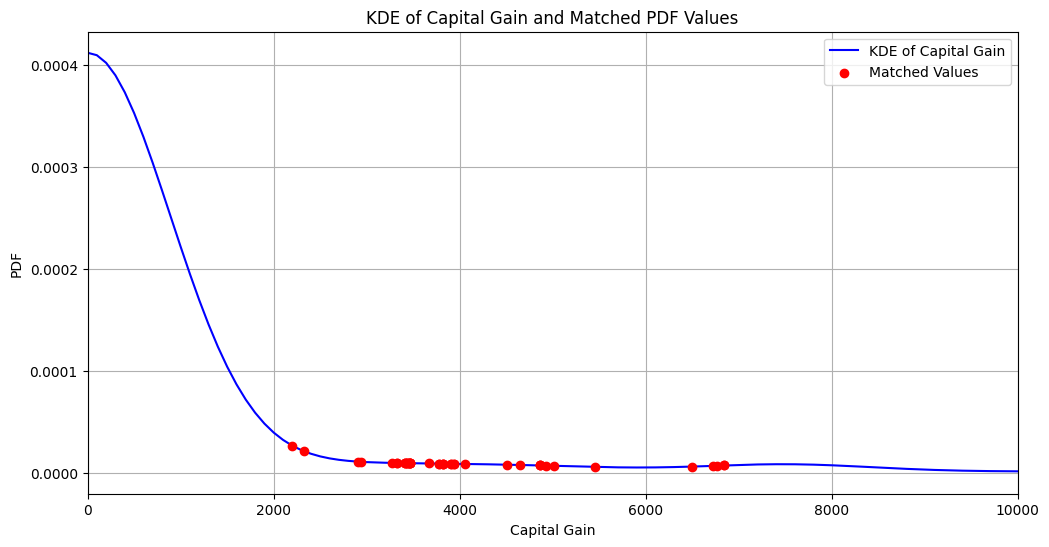

In [64]:
# Compute the KDE for the 'capital-gain'
kde = gaussian_kde(df['capital-gain'])

# Values to check
values = [
    1409, 1424, 1455, 1506, 1797, 2105, 2174, 2202, 2228, 2290, 2329, 2346, 2354,
    2407, 2414, 2463, 2580, 2597, 2635, 2653, 2829, 2885, 2907, 2936, 2961, 3137,
    3273, 3325, 3411, 3432, 3456, 3464, 3471, 3674, 3781, 3818, 3908, 3942, 4064,
    4101, 4416, 4508, 4650, 4865, 4931, 5013, 5455, 5721, 6360, 6497, 6723, 6767,
    6849, 7443, 7978, 10566, 22040, 34095, 41310
]

# Range values to compare
range_values = [
    1.108469510907749e-06, 5.765883500686317e-06, 6.10361661605396e-06, 6.812113570428972e-06,
    7.014401995094196e-06, 7.1738364190331214e-06, 7.194661828926502e-06, 7.660438928410234e-06,
    7.947687124397542e-06, 8.667196401393174e-06, 8.825617371877361e-06, 8.867547263415679e-06,
    8.974838428689815e-06, 9.017723059882917e-06, 9.383215882157025e-06, 9.392498484571787e-06,
    9.466276197254861e-06, 9.603682302865236e-06, 1.0040343731611617e-05, 1.0775653765085864e-05,
    1.0920757983701274e-05, 1.1258138748347011e-05, 1.170231032823149e-05, 1.3770732245764749e-05,
    1.405480988072596e-05, 1.502609359416476e-05, 1.910843724102672e-05, 1.9325712488370405e-05,
    2.1109643625328754e-05, 2.3619222072924518e-05, 2.6465815179851564e-05, 2.779276464904525e-05,
    2.9315798274844017e-05, 3.351370696288232e-05, 0.00010547658630157628, 0.00012424286014113114
]

# Compute the PDF values for `values`
pdf_values = [(value, kde(value)) for value in values]

# Check matches within a tolerance
tolerance = 1e-7
matches = [
    (value, pdf_value[0], range_value) 
    for (value, pdf_value) in pdf_values 
    for range_value in range_values 
    if abs(pdf_value[0] - range_value) <= tolerance
]

# Prepare for visualization
values_matched = [v for (v, _, _) in matches]
pdf_matched = [kde(v)[0] for v in values_matched]

# Plot the KDE and highlight matched values
x = np.linspace(min(df['capital-gain']), max(df['capital-gain']), 1000)
y = kde(x)

# Restrict the x-axis range to 0-10,000 for the plot
plt.figure(figsize=(12, 6))
plt.plot(x, y, label='KDE of Capital Gain', color='blue')
plt.scatter(values_matched, pdf_matched, color='red', label='Matched Values', zorder=5)
plt.title('KDE of Capital Gain and Matched PDF Values')
plt.xlabel('Capital Gain')
plt.ylabel('PDF')
plt.legend()
plt.grid(True)
plt.xlim(0, 10000)  # Restrict the x-axis range to 0-10,000
plt.show()